# Time series EDA

### The goal of this notebook is to run some time series EDA on the prize data

In [6]:
system_ids = [2105, 2107, 7333, 9068] #the relevant ids
system_id = 2105 #may have to look through them eventually
path = f'../../../../data_ds_project/systems/prize/{system_id}/'
path

'../../../../data_ds_project/systems/prize/2105/'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

#now more time-series specific things
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm

First, I will have to see how to read the prize data. It is comprised of CSV files contained in a folder each.

In [26]:
inv_01_data_2105 = pd.read_csv(f'{path}2105_inv01_data.csv')
display(inv_01_data_2105)
print(inv_01_data_2105['inv_string01_ac_output_(kwh)_inv_150164'].value_counts())
print(inv_01_data_2105['inv_string01_ac_output_(power_factor)_inv_150165'].value_counts())

,measured_on,inv_string01_ac_output_(kwh)_inv_150164,inv_string01_ac_output_(power_factor)_inv_150165,inv_string01_ac_voltage_(v)_inv_150163,inv_string01_dc_voltage_(v)_inv_150162,inv_string01_temperature_(c)_inv_150166
0,2018-12-29 06:45:00,0.0,0.0,123.891,0.0000,0.0000
1,2018-12-29 10:45:00,0.0,0.0,123.875,0.0000,0.0000
2,2018-12-29 20:45:00,0.0,0.0,121.844,0.0000,0.0000
3,2018-12-30 02:45:00,0.0,0.0,122.750,0.0000,0.0000
4,2018-12-30 16:45:00,0.0,0.0,121.672,0.0000,0.0000
...,...,...,...,...,...,...
318220,2023-11-14 17:47:00,0.0,NaN,123.109,344.8750,44.2145
318221,2023-11-14 17:52:00,0.0,NaN,123.172,83.7500,42.7904
318222,2023-11-14 17:57:00,0.0,NaN,123.250,15.0000,41.4790
318223,2023-11-14 19:47:00,0.0,NaN,123.016,5.6875,40.6923


inv_string01_ac_output_(kwh)_inv_150164
0.0000    85469
0.0020      226
0.0040      190
0.0060      176
0.0080      156
          ...  
7.0160        1
6.7160        1
0.0965        1
4.6005        1
4.8115        1
Name: count, Length: 6968, dtype: int64
inv_string01_ac_output_(power_factor)_inv_150165
1.000000    4610
0.000000    2609
0.500000     236
0.333333     211
0.400000     125
            ... 
0.970658       1
0.892377       1
0.981623       1
0.984161       1
0.489474       1
Name: count, Length: 76136, dtype: int64


In [33]:
inv_01_data_2105.info()

<class 'pandas.DataFrame'>
RangeIndex: 318224 entries, 0 to 318223
Data columns (total 8 columns):
 #   Column                                            Non-Null Count   Dtype         
---  ------                                            --------------   -----         
 0   measured_on                                       318224 non-null  str           
 1   inv_string01_ac_output_(kwh)_inv_150164           318224 non-null  float64       
 2   inv_string01_ac_output_(power_factor)_inv_150165  232574 non-null  float64       
 3   inv_string01_ac_voltage_(v)_inv_150163            318224 non-null  float64       
 4   inv_string01_dc_voltage_(v)_inv_150162            292444 non-null  float64       
 5   inv_string01_temperature_(c)_inv_150166           318223 non-null  float64       
 6   time                                              318224 non-null  datetime64[us]
 7   dt                                                318224 non-null  float64       
dtypes: datetime64[us](1), floa

In [27]:
#want measured_on to be a datetime object --> make a new column called time
inv_01_data_2105['time'] = pd.to_datetime(inv_01_data_2105['measured_on'])
inv_01_data_2105.sort_values(by = 'time', inplace = True) #make sure sorted by time
inv_01_data_2105

,measured_on,inv_string01_ac_output_(kwh)_inv_150164,inv_string01_ac_output_(power_factor)_inv_150165,inv_string01_ac_voltage_(v)_inv_150163,inv_string01_dc_voltage_(v)_inv_150162,inv_string01_temperature_(c)_inv_150166,time
0,2018-12-29 06:45:00,0.0,0.0,123.891,0.0000,0.0000,2018-12-29 06:45:00
1,2018-12-29 10:45:00,0.0,0.0,123.875,0.0000,0.0000,2018-12-29 10:45:00
2,2018-12-29 20:45:00,0.0,0.0,121.844,0.0000,0.0000,2018-12-29 20:45:00
3,2018-12-30 02:45:00,0.0,0.0,122.750,0.0000,0.0000,2018-12-30 02:45:00
4,2018-12-30 16:45:00,0.0,0.0,121.672,0.0000,0.0000,2018-12-30 16:45:00
...,...,...,...,...,...,...,...
318220,2023-11-14 17:47:00,0.0,NaN,123.109,344.8750,44.2145,2023-11-14 17:47:00
318221,2023-11-14 17:52:00,0.0,NaN,123.172,83.7500,42.7904,2023-11-14 17:52:00
318222,2023-11-14 17:57:00,0.0,NaN,123.250,15.0000,41.4790,2023-11-14 17:57:00
318223,2023-11-14 19:47:00,0.0,NaN,123.016,5.6875,40.6923,2023-11-14 19:47:00


In [38]:
#need to find the power, aka kWATTS, not kWh.
#will do this via approximations a la left Riemann sums

#step 1: find delta time
inv_01_data_2105['dt'] = inv_01_data_2105['time'].diff().shift(-1) / pd.Timedelta(hours=1)
inv_01_data_2105.dropna(subset=['dt'], inplace=True)

#step 2: divide
inv_01_data_2105['power'] = inv_01_data_2105['inv_string01_ac_output_(kwh)_inv_150164']/inv_01_data_2105['dt']
inv_01_data_2105


,measured_on,inv_string01_ac_output_(kwh)_inv_150164,inv_string01_ac_output_(power_factor)_inv_150165,inv_string01_ac_voltage_(v)_inv_150163,inv_string01_dc_voltage_(v)_inv_150162,inv_string01_temperature_(c)_inv_150166,time,dt,power
0,2018-12-29 06:45:00,0.000,0.000000,123.891,0.000,0.0000,2018-12-29 06:45:00,4.000000,0.000
1,2018-12-29 10:45:00,0.000,0.000000,123.875,0.000,0.0000,2018-12-29 10:45:00,10.000000,0.000
2,2018-12-29 20:45:00,0.000,0.000000,121.844,0.000,0.0000,2018-12-29 20:45:00,6.000000,0.000
3,2018-12-30 02:45:00,0.000,0.000000,122.750,0.000,0.0000,2018-12-30 02:45:00,14.000000,0.000
4,2018-12-30 16:45:00,0.000,0.000000,121.672,0.000,0.0000,2018-12-30 16:45:00,16.000000,0.000
...,...,...,...,...,...,...,...,...,...
318218,2023-11-14 17:37:00,0.069,0.076923,122.641,398.812,44.4270,2023-11-14 17:37:00,0.083333,0.828
318219,2023-11-14 17:42:00,0.016,0.000000,123.094,398.750,44.3664,2023-11-14 17:42:00,0.083333,0.192
318220,2023-11-14 17:47:00,0.000,NaN,123.109,344.875,44.2145,2023-11-14 17:47:00,0.083333,0.000
318221,2023-11-14 17:52:00,0.000,NaN,123.172,83.750,42.7904,2023-11-14 17:52:00,0.083333,0.000


(array([5733., 5726., 5730., 5713., 5721., 6001., 5036., 1830.,  845.,
         624.,  549.,  486.,  491.,  506.,  536.,  503.,  531., 1591.,
        5729., 7182., 6714., 6214., 5748., 5728.]),
 array([ 0.        ,  0.99930556,  1.99861111,  2.99791667,  3.99722222,
         4.99652778,  5.99583333,  6.99513889,  7.99444444,  8.99375   ,
         9.99305556, 10.99236111, 11.99166667, 12.99097222, 13.99027778,
        14.98958333, 15.98888889, 16.98819444, 17.9875    , 18.98680556,
        19.98611111, 20.98541667, 21.98472222, 22.98402778, 23.98333333]),
 <BarContainer object of 24 artists>)

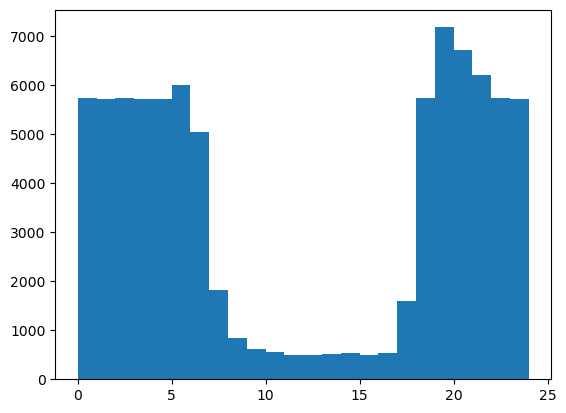

In [42]:
#When does power = 0? likely at night. Let's investigate...

zero_pow = inv_01_data_2105.loc[inv_01_data_2105['power']==0]
#plot histogram
#x=axis = # hours since midnight
hours = zero_pow['time'].dt.hour + zero_pow['time'].dt.minute/60 + zero_pow['time'].dt.second/3600

plt.hist(hours, bins = 24)